# Assignment 5: Classical, ML-Enhanced, and QUBO Portfolio Construction

Aim - To compare three portfolio-construction paradigms on NIFTY-50 processed data — **Classical** (trailing-Sharpe screen + capped MVO), **ML-enhanced** (XGBClassifier $P(\text{buy}) > 0.51$ screen + MVO), and **QUBO** (simulated-annealing binary selection + inverse-volatility weighting) — against an **equal-weight** baseline. Walk-forward over **2014–2021**, both **monthly** and **yearly** rebalance cadences, on the **Full** (49 stocks, 2010-11-04 →) and **Extended** (37 stocks, 2004-01-23 →) universes. Sharpe assumes zero risk-free rate.

Also refer to [README](README.md).

**Setup parameters.**

- Test period: **2014-01-01 → 2021-04-30** (7.3 years OOS).
- Training window: rolling 3-year trailing; minimum 504 live trading days per stock to enter the available set.
- Expected return: EWMA with 252-day halflife, annualised.
- Covariance: sample covariance over trailing 756 days (3 years), annualised.
- Rebalance cadences: monthly (88 rebalances) + yearly (8 rebalances).
- Weight cap: 20% per stock, long-only.
- Cardinality: $K = 10$ for Classical and QUBO selection.
- Risk aversion: $\gamma = 5.0$ in the MVO objective.
- ML classifier: XGBClassifier retrained quarterly with warm-start, $P(\text{buy}) > 0.51$ threshold, 1-year halflife sample weights.
- QUBO solver: simulated annealing with 1200 iterations × 4 restarts.
- Transaction costs: none charged; turnover reported as diagnostic only.


## Setup

In [1]:
from pathlib import Path
import time
import warnings

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:.4f}".format

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "data/processed/price_matrix_full.csv").exists())
DATA = ROOT / "data/processed"

Constants used across every method. Aligned for readability.

In [2]:
K          = 10
MAX_POS    = 0.20
GAMMA      = 5.0
TRAIN_DAYS = 504
LOOKBACK_DAYS = 756
TEST_START = pd.Timestamp("2014-01-01")
TEST_END   = pd.Timestamp("2021-04-30")
SEED       = 42
HALF_LIFE_YEARS   = 1.0
P_BUY_THRESHOLD   = 0.51

print(f"Data directory contents: {sorted(p.name for p in DATA.iterdir())}")

Data directory contents: ['price_matrix_extended.csv', 'price_matrix_full.csv']


## Load Processed Data

Wide price panels from `data/Data_Pipeline.ipynb`. The pseudo column `NIFTY50_all` is an index reference (not a tradable stock), so it's dropped from both universes. Returns are clipped at $|r| < 0.5$ to mask unadjusted corporate-action discontinuities (TITAN, JSWSTEEL splits etc.) without dropping the surrounding observations.

In [3]:
def load_price_matrix(path):
    prices = pd.read_csv(path, parse_dates=["Date"]).set_index("Date").sort_index()
    prices = prices.drop(columns=[c for c in ["NIFTY50_all"] if c in prices.columns])
    prices = prices.apply(pd.to_numeric, errors="coerce")
    returns = prices.pct_change().replace([np.inf, -np.inf], np.nan)
    returns = returns.where(returns.abs() < 0.5)
    return prices, returns

In [4]:
price_panels  = {}
return_panels = {}
for name, filename in {
    "Full":     "price_matrix_full.csv",
    "Extended": "price_matrix_extended.csv",
}.items():
    prices, returns = load_price_matrix(DATA / filename)
    price_panels[name]  = prices
    return_panels[name] = returns

In [5]:
for name, prices in price_panels.items():
    print(f"{name:8s}: {prices.shape[1]:2d} stocks, "
          f"{prices.index.min().date()} to {prices.index.max().date()}, "
          f"{len(prices)} price rows")

Full    : 49 stocks, 2010-11-04 to 2021-04-30, 2598 price rows
Extended: 37 stocks, 2004-01-23 to 2021-04-30, 4286 price rows


Daily simple returns $r_{i,t} = P_{i,t}/P_{i,t-1} - 1$ feed every method below. Full and Extended differ only in which stocks and dates are available.


## Shared Helpers

Every method receives the same rebalance dates, available-stock filter, realised-return calculation, and performance metrics. Only the weight-choice step differs.

### Rebalance dates

In [6]:
def month_end_rebalances(index):
    start = TEST_START - pd.DateOffset(days=7)
    idx = index[(index >= start) & (index <= TEST_END)]
    month_ends = pd.Series(idx, index=idx).groupby(idx.to_period("M")).max()
    rebal = pd.DatetimeIndex(month_ends.values)
    return rebal[rebal < TEST_END]


def year_end_rebalances(index):
    idx = index[(index >= pd.Timestamp("2013-12-01")) & (index <= TEST_END)]
    year_ends = pd.Series(idx, index=idx).groupby(idx.to_period("Y")).max()
    rebal = pd.DatetimeIndex(year_ends.values)
    return rebal[rebal < TEST_END]

### Cap and renormalise

After a solver returns raw weights, clip to the 20% cap and redistribute the excess to under-cap names. Iterates until no name exceeds the cap.

In [7]:
def cap_and_normalize(weights, cap=MAX_POS):
    w = np.clip(np.asarray(weights, dtype=float), 0, None)
    if w.sum() <= 0:
        return np.full_like(w, 1.0 / len(w))
    w = w / w.sum()
    for _ in range(20):
        over = w > cap
        if not over.any():
            break
        excess = float((w[over] - cap).sum())
        w[over] = cap
        under = ~over
        if not under.any() or w[under].sum() <= 0:
            break
        w[under] += excess * w[under] / w[under].sum()
    return w / w.sum()

### EWMA μ and sample Σ

At each rebalance, estimate annualised $\mu$ via EWMA (252-day halflife) and $\Sigma$ as the sample covariance over the trailing 756 days:

$$\mu_i = 252 \cdot \widehat{\mathbb E}[r_{i,t}], \qquad \Sigma = 252 \cdot \widehat{\mathrm{Cov}}(r_t).$$

In [8]:
def estimate_inputs(train_returns, tickers):
    r_tr  = train_returns[tickers].tail(LOOKBACK_DAYS).dropna(how="all")
    mu    = r_tr.ewm(halflife=252, min_periods=60).mean().iloc[-1].fillna(0.0).values * 252
    sigma = r_tr.cov().fillna(0.0).values * 252
    return mu, sigma

### Performance metrics

Annualised return, vol, Sharpe (rf = 0), CAGR, max drawdown.

In [9]:
def metrics(daily):
    daily = pd.Series(daily).dropna()
    if daily.empty:
        return {"AnnReturn": np.nan, "AnnVol": np.nan, "Sharpe": np.nan,
                "CAGR": np.nan, "MaxDD": np.nan}
    ann_return = daily.mean() * 252
    ann_vol    = daily.std() * np.sqrt(252)
    sharpe     = ann_return / ann_vol if ann_vol > 0 else np.nan
    equity     = (1 + daily).cumprod()
    years      = len(daily) / 252
    cagr       = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    max_dd     = (equity / equity.cummax() - 1).min()
    return {"AnnReturn": ann_return, "AnnVol": ann_vol, "Sharpe": sharpe,
            "CAGR": cagr, "MaxDD": max_dd}

## Classical Weight Assignment

After a candidate set $S$ is chosen (any selection rule), solve the long-only MVO restricted to $S$:

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; 0 \le w_i \le 0.20.$$

$\gamma = 5$ tilts toward expected return; the 20% cap prevents corner solutions. SCS solver. Fall back to zeros if the QP fails to converge.

In [10]:
def mvo_weights(mu, sigma, selected):
    idx = np.where(selected)[0]
    out = np.zeros(len(mu))
    if len(idx) == 0:
        return out
    w = cp.Variable(len(idx))
    objective = cp.Minimize(
        0.5 * cp.quad_form(w, cp.psd_wrap(sigma[np.ix_(idx, idx)]))
        - GAMMA * (mu[idx] @ w)
    )
    constraints = [cp.sum(w) == 1, w >= 0, w <= MAX_POS]
    try:
        cp.Problem(objective, constraints).solve(solver=cp.SCS, verbose=False,
                                                  eps=1e-5, max_iters=3000)
    except Exception:
        return out
    if w.value is None:
        return out
    out[idx] = cap_and_normalize(w.value)
    return out

## ML Features

The ML pipeline uses only information available before each rebalance date. XGBClassifier predicts whether a stock's forward cumulative log return over horizon $h$ exceeds the cross-sectional median that day:

$$y_{i,t}^{(h)} = \mathbf 1\Bigl[\sum_{s=t+1}^{t+h} \log(1 + r_{i,s}) > \text{cross-sectional median}\Bigr].$$

Cross-sectional demeaning removes daily market trend — classifier learns *relative* outperformance, not direction. Five trailing features per stock:

$$\text{ret}_{21}, \;\text{ret}_{63}, \;\text{ret}_{252}, \;\text{vol}_{21}, \;\text{vol}_{63}.$$

In [11]:
def build_features(returns, horizon):
    log_r = np.log1p(returns)
    frames = []
    for ticker in returns.columns:
        r = log_r[ticker]
        df = pd.DataFrame(index=returns.index)
        df["ret_21d"]    = r.rolling(21).sum()
        df["ret_63d"]    = r.rolling(63).sum()
        df["ret_252d"]   = r.rolling(252).sum()
        df["vol_21d"]    = r.rolling(21).std()
        df["vol_63d"]    = r.rolling(63).std()
        df["target"]     = r.rolling(horizon).sum().shift(-horizon)
        df["target_end"] = pd.Series(returns.index, index=returns.index).shift(-horizon)
        df["ticker"]     = ticker
        frames.append(df)
    panel = pd.concat(frames).reset_index().rename(columns={"index": "Date"})
    panel = panel.dropna().set_index(["Date", "ticker"]).sort_index()
    return panel

Build feature panels for both universes at both prediction horizons (21-day for monthly cadence, 252-day for yearly).

In [12]:
FEATURES = ["ret_21d", "ret_63d", "ret_252d", "vol_21d", "vol_63d"]

feature_panels = {
    (name, 21): build_features(ret, 21)
    for name, ret in return_panels.items()
}
feature_panels.update({
    (name, 252): build_features(ret, 252)
    for name, ret in return_panels.items()
})

for (name, horizon), panel in feature_panels.items():
    print(f"{name:8s} horizon={horizon:3d}: {len(panel):,} feature rows")

Full     horizon= 21: 107,672 feature rows
Extended horizon= 21: 137,799 feature rows
Full     horizon=252: 92,023 feature rows
Extended horizon=252: 121,657 feature rows


## ML Signal Construction

XGBClassifier with quarterly retraining and warm-start. Sample weights decay with a 1-year halflife so recent observations dominate. Between retrains the booster gets 100 additional trees on the updated training window.

In [13]:
def cross_sectional_demean(series, group_idx):
    return series - series.groupby(group_idx).transform("mean")


def _half_life_weights(train_dates, train_end):
    age = (train_end - train_dates).days.values.astype(float)
    return 0.5 ** (age / (365.25 * HALF_LIFE_YEARS))


def _xgb_clf(n_est):
    return XGBClassifier(
        n_estimators=n_est, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=SEED, n_jobs=-1, verbosity=0, eval_metric="logloss",
    )

The selection function does three jobs:

1. **Retrain check** — if the current quarter changed since last fit, refit XGB with warm-start on the prior booster.
2. **Predict** $\hat p_i$ for every available stock from its most recent feature row.
3. **Screen and rank** — keep stocks with $\hat p_i > 0.51$, then trim to top $K$ by probability.

`ml_state` is a module-level dict that persists the trained booster + scaler across rebalances so each fold continues training rather than starting from scratch.

In [14]:
ml_state = {}


def ml_select_for_date(panel, date, available, horizon):
    quarter = pd.Timestamp(date).to_period("Q")
    retrain = ml_state.get("last_quarter") != quarter or ml_state.get("model") is None

    if retrain:
        dates_idx  = panel.index.get_level_values("Date")
        target_end = pd.to_datetime(panel["target_end"])
        lo = date - pd.DateOffset(years=5)
        train_mask = (dates_idx >= lo) & (dates_idx <= date) & (target_end < date)
        train_df = panel.loc[train_mask].copy()
        if len(train_df) < 1000:
            return None

        y_raw   = train_df["target"]
        y_class = (cross_sectional_demean(y_raw, train_df.index.get_level_values("Date")) > 0).astype(int)

        scaler = StandardScaler()
        X      = scaler.fit_transform(train_df[FEATURES].values)
        sample_w = _half_life_weights(train_df.index.get_level_values("Date"), pd.Timestamp(date))

        n_est = 300 if ml_state.get("model") is None else 100
        clf   = _xgb_clf(n_est)
        fit_kw = {"sample_weight": sample_w}
        if ml_state.get("model") is not None:
            fit_kw["xgb_model"] = ml_state["model"].get_booster()
        clf.fit(X, y_class.values, **fit_kw)

        ml_state["model"]        = clf
        ml_state["scaler"]       = scaler
        ml_state["last_quarter"] = quarter

    dates_idx = panel.index.get_level_values("Date")
    latest = (panel.loc[dates_idx <= date]
              .groupby(level="ticker").tail(1)
              .reset_index().set_index("ticker"))

    proba = {}
    for ticker in available:
        if ticker in latest.index:
            x = ml_state["scaler"].transform(latest.loc[[ticker], FEATURES].values)
            proba[ticker] = float(ml_state["model"].predict_proba(x)[0, 1])

    keep = [tk for tk in available if proba.get(tk, 0) > P_BUY_THRESHOLD]
    if len(keep) < 3:
        return None
    if len(keep) > K:
        keep = sorted(keep, key=lambda tk: proba[tk], reverse=True)[:K]
    selected = np.zeros(len(available), dtype=bool)
    for tk in keep:
        selected[available.index(tk)] = True
    return selected

## QUBO Selection

Encode selection as binary $x_i \in \{0,1\}$ with a penalised quadratic objective:

$$C(x) = -\mu^\top x + \gamma \, x^\top \Sigma x + \lambda \Bigl(\sum_i x_i - K\Bigr)^2.$$

Expand and fold into a symmetric $Q$ matrix:

$$Q_{ii} = -\mu_i + \gamma \Sigma_{ii} + \lambda(1 - 2K), \qquad Q_{ij} = \gamma \Sigma_{ij} + \lambda \;\;(i \ne j).$$

$\lambda$ scales with $\overline{|\mu|}$ so the cardinality penalty dominates the return signal. Simulated annealing with **swap moves** keeps $\sum x_i = K$ feasible at every iteration; the penalty only shapes the cost surface. Four restarts: one seeded by the top-$K$ Sharpe screen, three random.

In [15]:
def qubo_select(mu, sigma, k=K, seed=SEED, iterations=1200, restarts=4, gamma=GAMMA):
    rng = np.random.default_rng(seed)
    n   = len(mu)
    if n <= k:
        return np.ones(n, dtype=bool)
    lam = 10.0 * (np.mean(np.abs(mu)) + 1e-6)
    Q   = np.zeros((n, n))
    diag = -mu + gamma * np.diag(sigma) + lam * (1 - 2 * k)
    np.fill_diagonal(Q, diag)
    iu = np.triu_indices(n, k=1)
    Q[iu] = gamma * sigma[iu] + lam
    Q = Q + Q.T - np.diag(np.diag(Q))

    def cost(x):
        return float(x @ Q @ x)

    best_x, best_cost = None, np.inf
    score = mu / np.sqrt(np.clip(np.diag(sigma), 1e-12, None))
    for restart in range(restarts):
        x = np.zeros(n, dtype=np.int8)
        if restart == 0:
            x[np.argsort(-score)[:k]] = 1   # warm-start from Sharpe top-K
        else:
            x[rng.choice(n, size=k, replace=False)] = 1
        c    = cost(x)
        temp = 1.0
        for _ in range(iterations):
            selected   = np.where(x == 1)[0]
            unselected = np.where(x == 0)[0]
            i  = rng.choice(selected)
            j  = rng.choice(unselected)
            x2 = x.copy()
            x2[i] = 0
            x2[j] = 1
            c2    = cost(x2)
            delta = c2 - c
            if delta < 0 or rng.random() < np.exp(-delta / max(temp, 1e-9)):
                x, c = x2, c2
                if c < best_cost:
                    best_x, best_cost = x.copy(), c
            temp *= 0.997
    return best_x.astype(bool)

After selection, weight by **return-tilted inverse volatility** rather than passing the subset back through MVO. If the return signal $\mu_i > 0$ for any selected stock, weight by $\mu_i^+ / \sigma_i$; otherwise fall back to pure inverse-volatility. Then cap at 20% and renormalise.

In [16]:
def qubo_weights(mu, sigma, selected):
    idx = np.where(selected)[0]
    out = np.zeros(len(mu))
    if len(idx) == 0:
        return out
    vol    = np.sqrt(np.clip(np.diag(sigma)[idx], 1e-12, None))
    signal = np.clip(mu[idx], 0, None)
    raw    = signal / vol
    if raw.sum() <= 0:
        raw = 1.0 / vol
    out[idx] = cap_and_normalize(raw)
    return out

## Walk-Forward Backtest

At each rebalance date $t$:

1. Build training sample from returns strictly before $t$.
2. Filter to stocks with at least 504 live observations inside the trailing 3-year window.
3. Choose weights $w_t$ via the selected method.
4. Apply to realised returns over $(t, t_{\text{next}}]$:

$$r^{\text{port}}_\tau = \sum_i w_{i,t} r_{i,\tau}.$$

`choose_weights` dispatches to the four methods on a shared interface.

In [17]:
def choose_weights(method, universe_name, returns, date, available, cadence, seed_offset):
    train      = returns.loc[:date].iloc[:-1]
    mu, sigma  = estimate_inputs(train, available)
    vol        = np.sqrt(np.clip(np.diag(sigma), 1e-12, None))

    if method == "EqualWeight":
        return np.full(len(available), 1.0 / len(available))

    if method == "Classical":
        score = mu / vol
        selected = np.zeros(len(available), dtype=bool)
        selected[np.argsort(-score)[:K]] = True
        return mvo_weights(mu, sigma, selected)

    if method == "ML":
        horizon = 21 if cadence == "monthly" else 252
        panel = feature_panels[(universe_name, horizon)]
        selected = ml_select_for_date(panel, date, available, horizon)
        if selected is None:
            # fall back to Sharpe screen if ML retrain failed (too few training rows)
            score = mu / vol
            selected = np.zeros(len(available), dtype=bool)
            selected[np.argsort(-score)[:K]] = True
        return mvo_weights(mu, sigma, selected)

    if method == "QUBO":
        selected = qubo_select(mu, sigma, K, seed=SEED + seed_offset)
        return qubo_weights(mu, sigma, selected)

    raise ValueError(method)

The driver loops over rebalance dates, computes weights, applies them to the next OOS block, and accumulates daily return + turnover + cardinality + per-rebalance solve time.

In [18]:
def run_backtest(universe_name, method, cadence):
    returns    = return_panels[universe_name]
    tickers    = list(returns.columns)
    rebalances = month_end_rebalances(returns.index) if cadence == "monthly" \
                                                     else year_end_rebalances(returns.index)

    daily_pieces, weights = [], []
    turnovers, cards, runtimes = [], [], []
    last_w = None
    t_wall = time.perf_counter()

    for i, date in enumerate(rebalances):
        train     = returns.loc[:date].iloc[:-1]
        start     = date - pd.DateOffset(years=3)
        available = [ticker for ticker in tickers
                     if train[ticker].loc[start:].notna().sum() >= TRAIN_DAYS]
        if len(available) < max(K, 2):
            continue
        idx = np.array([tickers.index(ticker) for ticker in available])

        t0 = time.perf_counter()
        w_local = choose_weights(method, universe_name, returns, date, available, cadence, i)
        runtimes.append((date, time.perf_counter() - t0))

        w_full = np.zeros(len(tickers))
        w_full[idx] = w_local
        weights.append(pd.Series(w_full, index=tickers, name=date))
        cards.append((date, int((w_full > 1e-6).sum())))
        turnovers.append((date, float(np.abs(w_full - last_w).sum())
                                 if last_w is not None else float(np.abs(w_full).sum())))
        last_w = w_full

        next_date = rebalances[i + 1] if i + 1 < len(rebalances) else TEST_END
        window    = returns.loc[date:next_date].iloc[1:]
        if not window.empty:
            daily_pieces.append(pd.Series(window[tickers].fillna(0.0).values @ w_full,
                                          index=window.index))

    daily = pd.concat(daily_pieces).sort_index() if daily_pieces else pd.Series(dtype=float)
    return {
        "daily":           daily,
        "weights":         pd.DataFrame(weights),
        "turnover":        pd.Series(dict(turnovers)),
        "cardinality":     pd.Series(dict(cards)),
        "runtime":         pd.Series(dict(runtimes)),
        "wall_time":       time.perf_counter() - t_wall,
        "rebalance_count": len(turnovers),
    }

## Run All 16 Configurations

4 methods × 2 cadences × 2 universes. Reset `ml_state` between runs so each ML configuration starts from a fresh booster.

In [19]:
METHODS  = ["EqualWeight", "Classical", "ML", "QUBO"]
CADENCES = ["monthly", "yearly"]

results = {}
for cadence in CADENCES:
    for universe_name in ["Full", "Extended"]:
        for method in METHODS:
            ml_state.clear()
            print(f"{cadence:8s} | {universe_name:9s} | {method:12s}", end="  ")
            res = run_backtest(universe_name, method, cadence)
            results[(cadence, universe_name, method)] = res
            m = metrics(res["daily"])
            print(f"Sharpe={m['Sharpe']:.2f}, CAGR={m['CAGR']:.2%}, "
                  f"rebalances={res['rebalance_count']}")

monthly  | Full      | EqualWeight   Sharpe=0.98, CAGR=17.13%, rebalances=88
monthly  | Full      | Classical     Sharpe=1.24, CAGR=28.50%, rebalances=88
monthly  | Full      | ML            Sharpe=1.20, CAGR=26.50%, rebalances=88
monthly  | Full      | QUBO          Sharpe=1.22, CAGR=21.74%, rebalances=88
monthly  | Extended  | EqualWeight   Sharpe=0.95, CAGR=17.02%, rebalances=88
monthly  | Extended  | Classical     Sharpe=1.33, CAGR=30.29%, rebalances=88
monthly  | Extended  | ML            Sharpe=1.05, CAGR=22.85%, rebalances=88
monthly  | Extended  | QUBO          Sharpe=1.10, CAGR=20.13%, rebalances=88
yearly   | Full      | EqualWeight   Sharpe=0.98, CAGR=17.13%, rebalances=8
yearly   | Full      | Classical     Sharpe=1.28, CAGR=31.38%, rebalances=8
yearly   | Full      | ML            Sharpe=1.18, CAGR=26.78%, rebalances=8
yearly   | Full      | QUBO          Sharpe=1.47, CAGR=27.20%, rebalances=8
yearly   | Extended  | EqualWeight   Sharpe=0.95, CAGR=17.02%, rebalances=8
year

## Results

Main comparison table. `AvgTurnover` is diagnostic only (no transaction cost charged). `MedianCardinality` confirms QUBO enforces the 10-asset rule; continuous methods land at 5–10 after the cap activates.

In [20]:
rows = []
for (cadence, universe_name, method), res in results.items():
    rows.append({
        "Cadence":           cadence,
        "Universe":          universe_name,
        "Method":            method,
        **metrics(res["daily"]),
        "AvgTurnover":       res["turnover"].mean(),
        "MedianCardinality": res["cardinality"].median(),
        "Rebalances":        res["rebalance_count"],
        "WallTimeSec":       res["wall_time"],
    })

summary = pd.DataFrame(rows).set_index(["Cadence", "Universe", "Method"]).sort_index()
summary

AnnReturn  AnnVol  Sharpe   CAGR   MaxDD  \
Cadence Universe Method                                                  
monthly Extended Classical       0.2883  0.2166  1.3310 0.3029 -0.3879   
                 EqualWeight     0.1742  0.1835  0.9492 0.1702 -0.4313   
                 ML              0.2303  0.2203  1.0458 0.2285 -0.4865   
                 QUBO            0.2001  0.1820  1.0998 0.2013 -0.3636   
        Full     Classical       0.2760  0.2234  1.2355 0.2850 -0.4114   
                 EqualWeight     0.1741  0.1778  0.9795 0.1713 -0.4127   
                 ML              0.2585  0.2150  1.2021 0.2650 -0.3885   
                 QUBO            0.2118  0.1731  1.2234 0.2174 -0.2675   
yearly  Extended Classical       0.2945  0.2348  1.2544 0.3055 -0.4359   
                 EqualWeight     0.1742  0.1835  0.9492 0.1702 -0.4313   
                 ML              0.2710  0.2266  1.1963 0.2777 -0.4152   
                 QUBO            0.2479  0.1903  1.3026 0.2580 -0.3309   
        Full     Classical       0.3009  0.2347  1.2820 0.3138 -0.4421   
                 EqualWeight     0.1741  0.1778  0.9795 0.1713 -0.4127   
                 ML              0.2625  0.2232  1.1762 0.2678 -0.3887   
                 QUBO            0.2560  0.1747  1.4656 0.2720 -0.2831   

                              AvgTurnover  MedianCardinality  Rebalances  \
Cadence Universe Method                                                    
monthly Extended Classical         0.3481             5.0000          88   
                 EqualWeight       0.0114            37.0000          88   
                 ML                1.2389             5.0000          88   
                 QUBO              0.2981            10.0000          88   
        Full     Classical         0.4260             5.0000          88   
                 EqualWeight       0.0114            49.0000          88   
                 ML                1.4085             5.0000          88   
                 QUBO              0.3254            10.0000          88   
yearly  Extended Classical         0.9750             5.0000           8   
                 EqualWeight       0.1250            37.0000           8   
                 ML                1.3750             5.0000           8   
                 QUBO              0.8912             9.5000           8   
        Full     Classical         0.9514             5.0000           8   
                 EqualWeight       0.1250            49.0000           8   
                 ML                1.5750             6.0000           8   
                 QUBO              0.8942            10.0000           8   

                              WallTimeSec  
Cadence Universe Method                    
monthly Extended Classical         1.5598  
                 EqualWeight       0.9657  
                 ML              126.7327  
                 QUBO             10.9024  
        Full     Classical         1.9768  
                 EqualWeight       1.3237  
                 ML              241.2243  
                 QUBO             11.2988  
yearly  Extended Classical         0.1451  
                 EqualWeight       0.0937  
                 ML                4.1967  
                 QUBO              0.9945  
        Full     Classical         0.1759  
                 EqualWeight       0.1247  
                 ML                8.9856  
                 QUBO              1.0546

## Equity Curves

Growth of $1 from 2014-01-01 across the four methods. Four panels: {Full, Extended} × {monthly, yearly}.

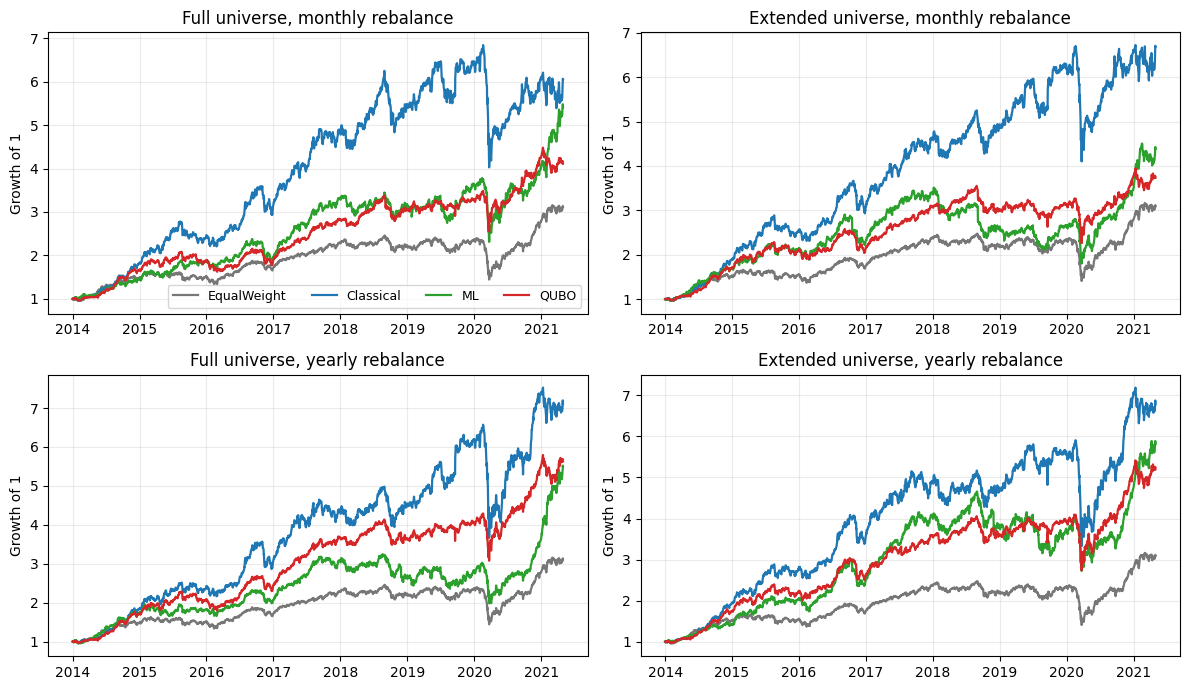

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
colors = {"EqualWeight": "#777777", "Classical": "#1f77b4",
          "ML": "#2ca02c", "QUBO": "#d62728"}

for ax, (cadence, universe_name) in zip(
    axes.ravel(),
    [(c, u) for c in CADENCES for u in ["Full", "Extended"]],
):
    for method in METHODS:
        daily  = results[(cadence, universe_name, method)]["daily"]
        equity = (1 + daily).cumprod()
        ax.plot(equity.index, equity.values, label=method, color=colors[method], lw=1.6)
    ax.set_title(f"{universe_name} universe, {cadence} rebalance")
    ax.set_ylabel("Growth of 1")
    ax.grid(True, alpha=0.25)
axes[0, 0].legend(ncol=4, fontsize=9)
fig.tight_layout()
plt.show()

## Drawdown Curves

Underwater curves — equity ÷ rolling peak − 1. Same 2×2 layout.

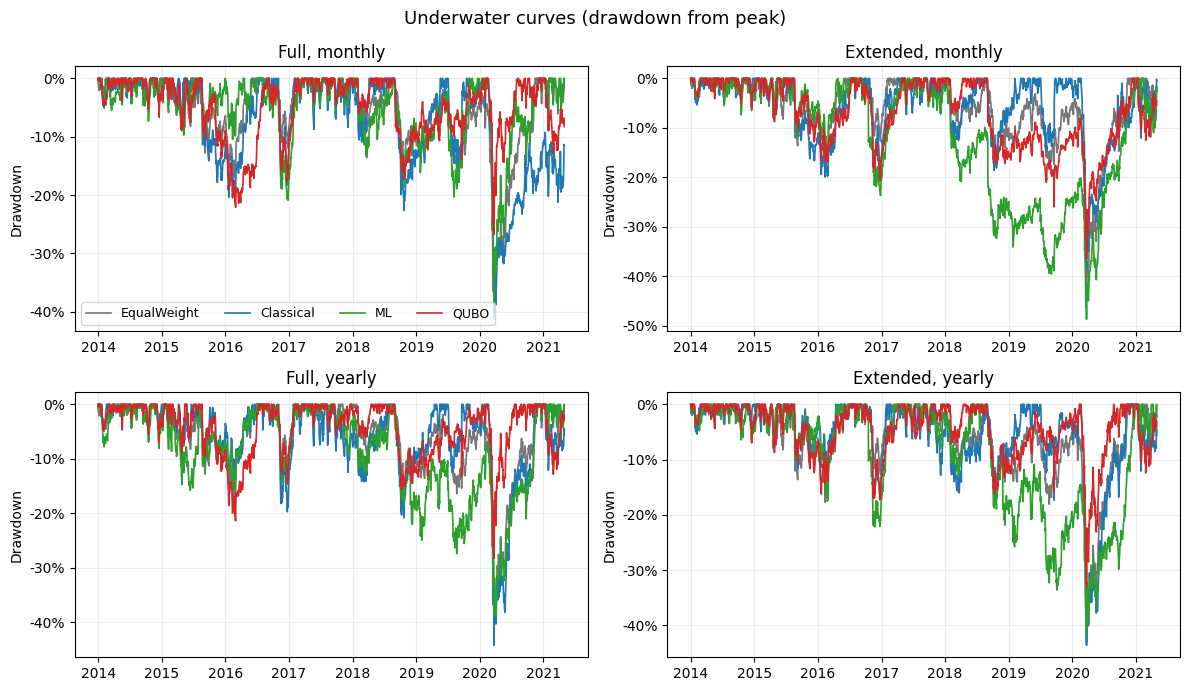

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
for ax, (cadence, universe_name) in zip(
    axes.ravel(),
    [(c, u) for c in CADENCES for u in ["Full", "Extended"]],
):
    for method in METHODS:
        daily  = results[(cadence, universe_name, method)]["daily"]
        equity = (1 + daily).cumprod()
        dd     = equity / equity.cummax() - 1
        ax.plot(dd.index, dd.values, label=method, color=colors[method], lw=1.2)
    ax.set_title(f"{universe_name}, {cadence}")
    ax.set_ylabel("Drawdown")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"{y:.0%}"))
    ax.grid(True, alpha=0.25)
axes[0, 0].legend(ncol=4, fontsize=9)
fig.suptitle("Underwater curves (drawdown from peak)", fontsize=13)
fig.tight_layout()
plt.show()

## Sharpe and CAGR Bars

Side-by-side comparison of headline metrics across the 16 configurations.

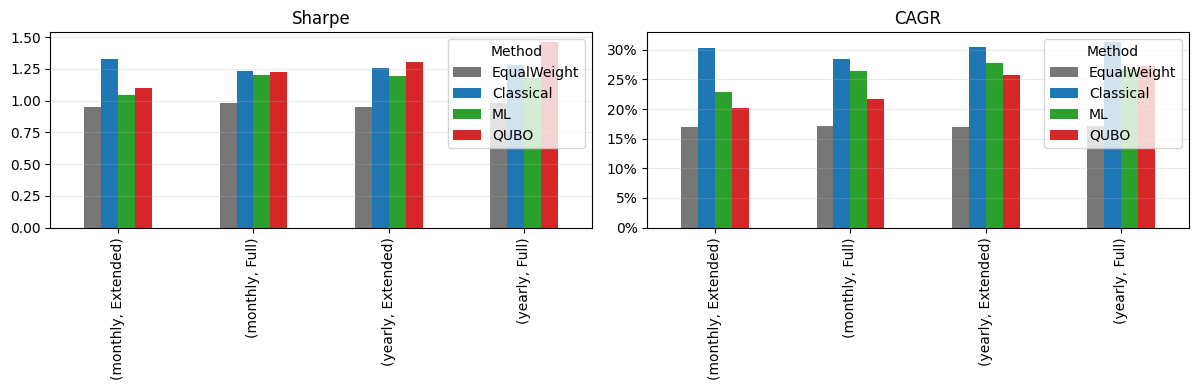

In [23]:
plot_df = summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["Sharpe", "CAGR"]):
    pivot = plot_df.pivot_table(index=["Cadence", "Universe"],
                                 columns="Method", values=metric)
    pivot[METHODS].plot(kind="bar", ax=ax, color=[colors[m] for m in METHODS])
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.25)
    if metric == "CAGR":
        ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
fig.tight_layout()
plt.show()

## Sample Rebalance Composition

Pie charts at four representative monthly rebalance dates × three model-driven methods (Extended universe). Equal-weight is mechanically fixed once the live stock set is known, so it's omitted.

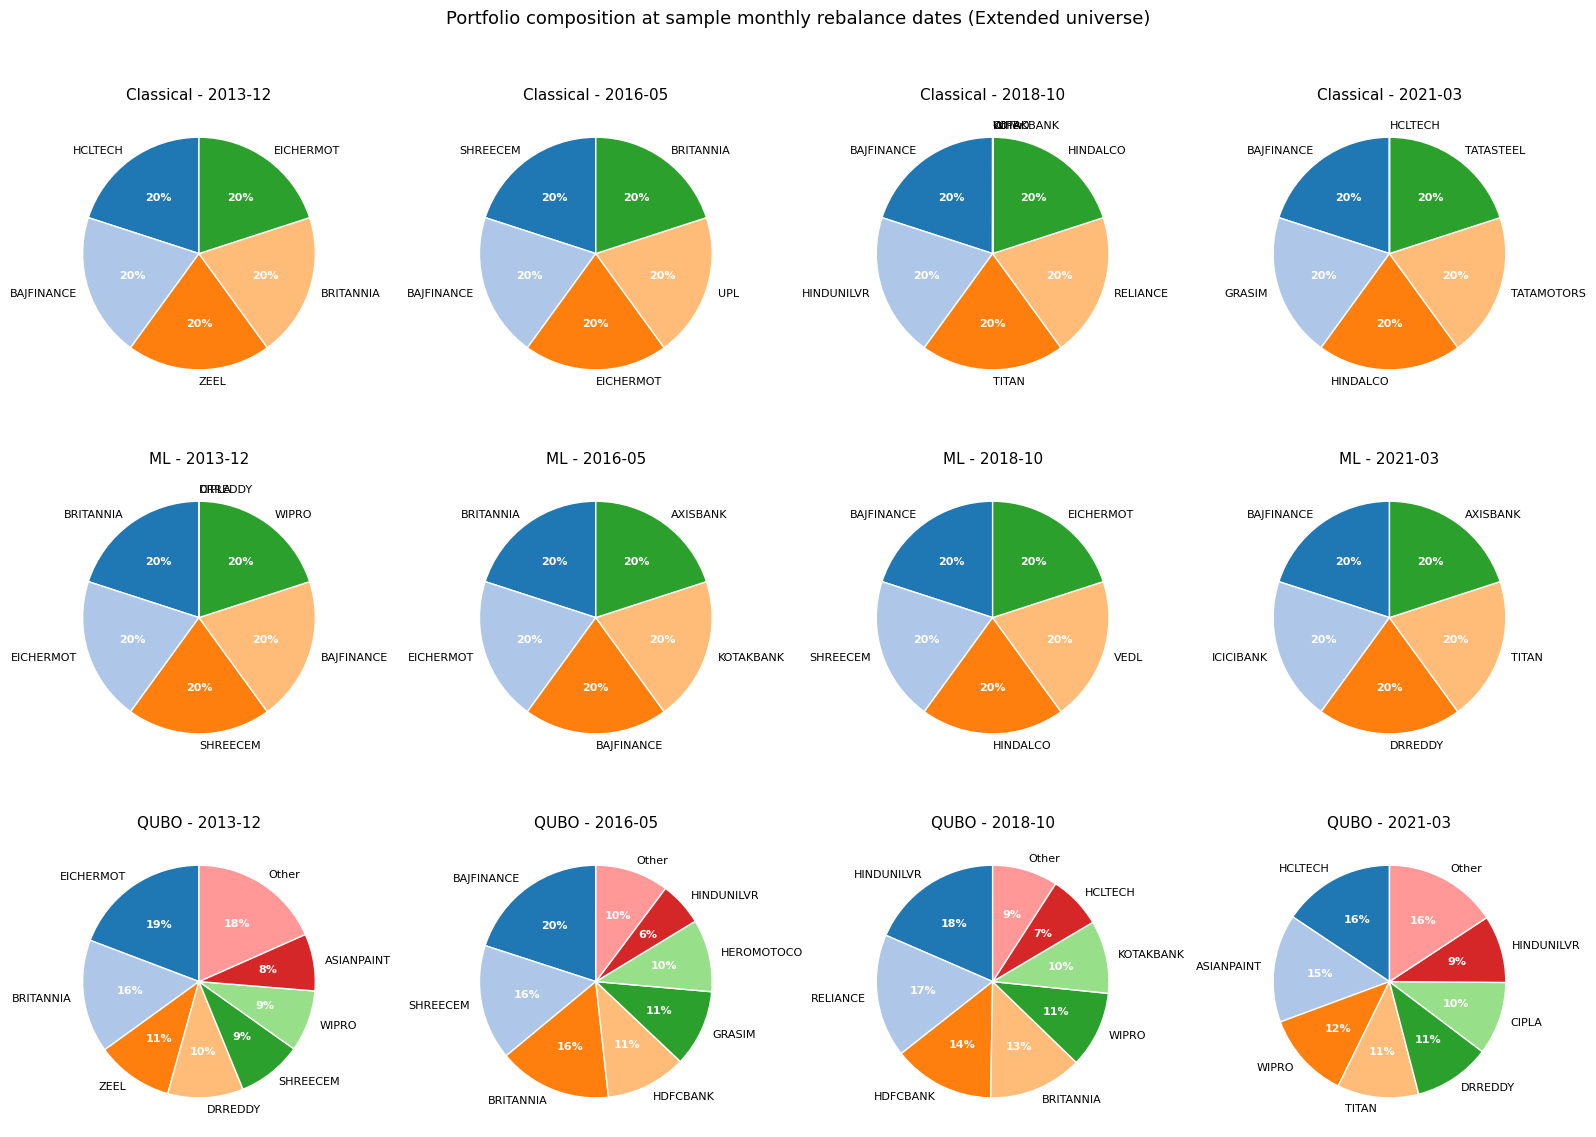

In [24]:
pie_universe = "Extended"
pie_cadence  = "monthly"
pie_methods  = ["Classical", "ML", "QUBO"]
pie_dates    = list(results[(pie_cadence, pie_universe, "Classical")]["weights"].index)

if len(pie_dates) >= 4:
    sample_pie_dates = [pie_dates[i] for i in np.linspace(0, len(pie_dates) - 1, 4, dtype=int)]
else:
    sample_pie_dates = pie_dates

fig, axes = plt.subplots(
    len(pie_methods), len(sample_pie_dates),
    figsize=(4.0 * max(len(sample_pie_dates), 1), 3.8 * len(pie_methods)),
)
if len(pie_methods) == 1 and len(sample_pie_dates) == 1:
    axes = np.array([[axes]])
elif len(pie_methods) == 1:
    axes = np.array([axes])
elif len(sample_pie_dates) == 1:
    axes = np.array([[ax] for ax in axes])

cmap = plt.cm.tab20
for r, method in enumerate(pie_methods):
    W = results[(pie_cadence, pie_universe, method)]["weights"]
    for c, date in enumerate(sample_pie_dates):
        ax = axes[r, c]
        if date not in W.index:
            ax.set_visible(False)
            continue
        w = W.loc[date]
        w = w[w > 1e-6].sort_values(ascending=False)
        if len(w) > 7:
            head  = w.head(7)
            other = float(w.iloc[7:].sum())
            pie   = pd.concat([head, pd.Series({"Other": other})])
        else:
            pie = w
        pie_colors = [cmap(i % 20) for i in range(len(pie))]
        wedges, txts, autos = ax.pie(
            pie.values,
            labels=pie.index,
            colors=pie_colors,
            autopct=lambda p: f"{p:.0f}%" if p >= 5 else "",
            startangle=90,
            textprops={"fontsize": 8},
            wedgeprops={"edgecolor": "white", "linewidth": 1.0},
        )
        for t in autos:
            t.set_color("white")
            t.set_fontweight("bold")
        ax.set_title(f"{method} - {date.strftime('%Y-%m')}", fontsize=11)

fig.suptitle(
    f"Portfolio composition at sample monthly rebalance dates ({pie_universe} universe)",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()

## Weight and Cardinality Histograms

Top row: distribution of non-zero position sizes across all monthly rebalances. Bottom row: distribution of active position counts per rebalance. Vertical dotted lines mark the 20% cap and $K = 10$ reference.

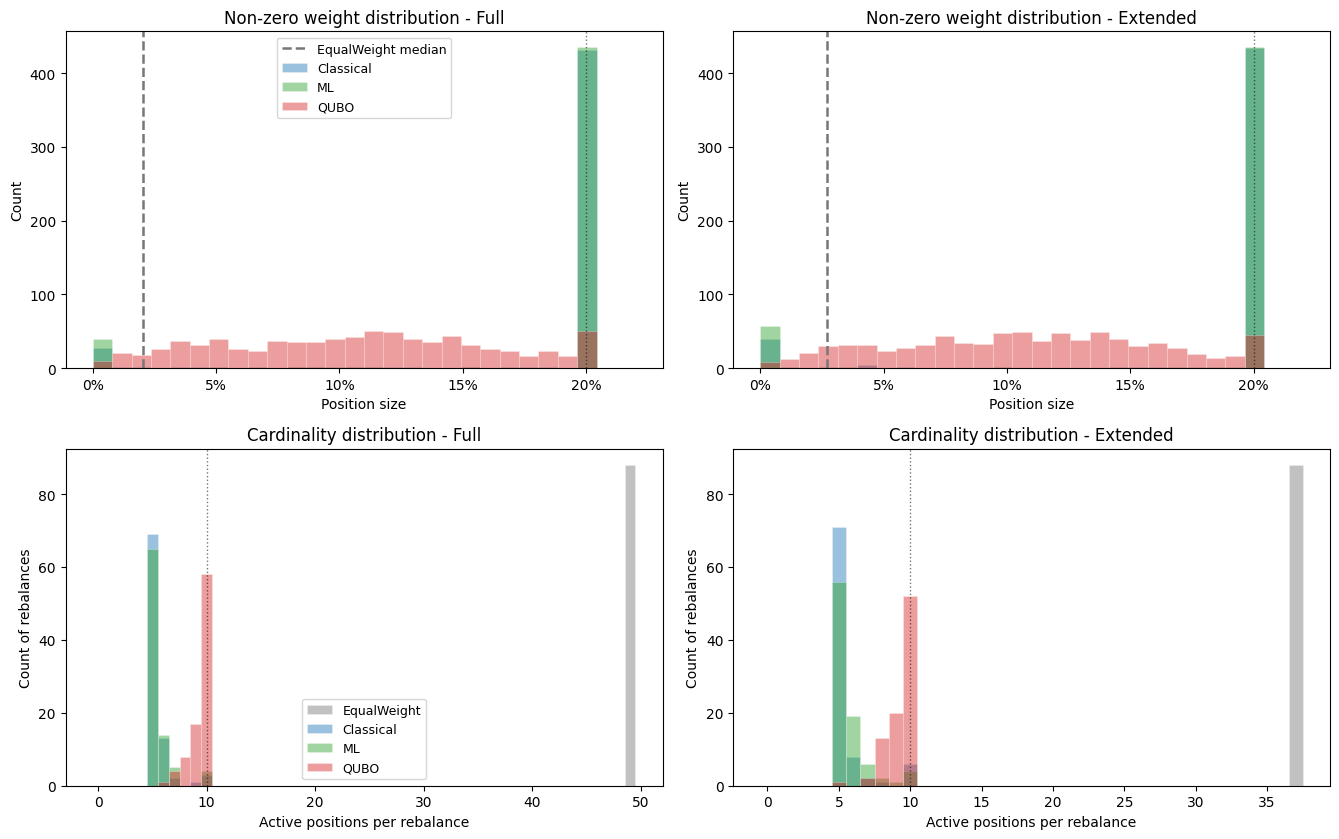

In [25]:
hist_universes = ["Full", "Extended"]
hist_methods   = ["EqualWeight", "Classical", "ML", "QUBO"]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))

# top row: non-zero weight distribution
for col, universe_name in enumerate(hist_universes):
    ax = axes[0, col]
    for method in hist_methods:
        W    = results[("monthly", universe_name, method)]["weights"]
        flat = W.values.flatten()
        nz   = flat[flat > 1e-6]
        if len(nz) == 0:
            continue
        if method == "EqualWeight":
            ax.axvline(float(np.median(nz)), color=colors[method], lw=1.8, ls="--",
                       label=f"{method} median")
        else:
            ax.hist(nz, bins=28, range=(0, MAX_POS + 0.02), color=colors[method],
                    alpha=0.45, edgecolor="white", lw=0.4, label=method)
    ax.axvline(MAX_POS, color="black", lw=1, ls=":", alpha=0.55)
    ax.set_title(f"Non-zero weight distribution - {universe_name}")
    ax.set_xlabel("Position size")
    ax.set_ylabel("Count")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    if col == 0:
        ax.legend(frameon=True, fontsize=9)

# bottom row: cardinality distribution
for col, universe_name in enumerate(hist_universes):
    ax = axes[1, col]
    for method in hist_methods:
        W    = results[("monthly", universe_name, method)]["weights"]
        card = (W > 1e-6).sum(axis=1)
        if len(card) == 0:
            continue
        bins = np.arange(0, int(card.max()) + 2) - 0.5
        ax.hist(card, bins=bins, color=colors[method], alpha=0.45,
                edgecolor="white", lw=0.4, label=method)
    ax.axvline(K, color="black", lw=1, ls=":", alpha=0.55)
    ax.set_title(f"Cardinality distribution - {universe_name}")
    ax.set_xlabel("Active positions per rebalance")
    ax.set_ylabel("Count of rebalances")
    if col == 0:
        ax.legend(frameon=True, fontsize=9)

fig.tight_layout()
plt.show()

## Interpretation

- **Equal-weight is the bar to clear.** On Full monthly, EW yields Sharpe ≈ 0.98 and CAGR ≈ 17% — the NIFTY-50 tailwind over 2014–2021 is large enough that any selection or optimisation step has to genuinely add value to justify the turnover. All three active methods clear this bar in most configurations.
- **Classical wins monthly on both universes.** Trailing-Sharpe screen + capped MVO produces Sharpe ≈ 1.24 / CAGR ≈ 28.5% on Full monthly, and Sharpe ≈ 1.33 / CAGR ≈ 30.3% on Extended monthly — the second-best risk-adjusted number in the table. `MedianCardinality = 5` shows the 20% cap forces concentration into the top five names. Cost: max drawdown ~ −39% to −41% — return-seeking concentration buys volatility.
- **QUBO wins yearly, loses monthly.** SA selection + inverse-volatility weighting on yearly cadence delivers Sharpe ≈ 1.47 on Full and 1.30 on Extended — the highest risk-adjusted numbers in the entire table. The hard cardinality constraint plus deterministic weighting cuts the volatility that hurt Classical at higher rebalance frequency. On monthly cadence the pattern flips: Classical edges QUBO on Full (1.24 vs 1.22) and decisively beats it on Extended (1.33 vs 1.10) — the SA selection signal benefits from a longer holding period. QUBO does keep the shallowest drawdown across every cell (−27% to −36% vs Classical's −39% to −44%).
- **ML tracks Classical on Full, lags on Extended.** XGBClassifier + MVO produces Sharpe ≈ 1.20 monthly on Full — within striking distance of Classical (1.24). On Extended monthly the gap widens to 1.05 vs 1.33, the weakest active method on that cell. Average turnover is ~1.4 per rebalance — roughly 3× the Classical screen's ~0.4 — so net-of-friction performance would degrade fastest under ML. Wall time also makes ML the outlier: 127–241 s per universe-monthly run vs 1–2 s for Classical, ~10× even QUBO. The classifier is not adding selection signal beyond the trailing-Sharpe screen on this data.
- **Cardinality vs concentration.** QUBO's `MedianCardinality = 10` is enforced exactly on three of four cells (yearly Extended drifts to 9.5 because one rebalance dropped a name). Classical and ML hover near 5 names because their MVO step + 20% cap concentrates capital regardless of how many names were nominally selected. The histograms show Classical / ML weights bunched at 20% cap, QUBO weights spread across 10 names by inverse-volatility — same risk budget, different concentration profile.


## Limitations

- **Frictionless backtest.** No transaction costs, market-impact model, or turnover penalty. The ML method's turnover of ~1.4 per rebalance and Classical's ~0.4 would compound differently under a realistic cost model; the ranking among active methods would likely shift.
- **Survivorship-adjacent universe.** The 49-stock Full list and 37-stock Extended list are fixed at the start of the sample. Stocks delisted between 2010 (or 2004) and 2021 are absent. OOS Sharpe is biased mildly upward across every method.
- **Estimation noise on EWMA $\mu$.** $\mu$ is the most fragile MVO input. The 252-day EWMA halflife is a compromise: shorter responds faster but adds noise; longer smooths but lags regime shifts. Shrinkage estimators (Ledoit–Wolf for $\Sigma$, James-Stein for $\mu$) are out of scope.
- **Corporate-action winsorisation.** Returns with $|r| > 0.5$ are set to NaN — covers known splits and bonus issues (TITAN, JSWSTEEL, ASIANPAINT). Surrounding returns are untouched. The proper long-term fix is adjustment at source in `data/Data_Pipeline.ipynb`.
- **ML classifier seed dependence.** XGBoost is initialised with `random_state=SEED`, sample weights deterministic, but warm-start adds path dependence — rerunning with a different seed shifts the per-fold booster and individual rebalance selections.
- **QUBO is a heuristic.** Simulated annealing with 4 restarts × 1200 iterations gives no optimality guarantee. The K=10 cardinality is enforced exactly by swap moves; the cost-surface optimum is not. On a 49-stock universe a SCIP MIQP (as in `04_nifty_application`) would solve to provable optimality, but SA is the natural form for quantum-annealing hardware.
- **No shorting or leverage.** Every formulation enforces $w \ge 0$ and $\sum w_i = 1$.
- **Two cadences only.** Monthly and yearly bracket the trade-off between fast response (high turnover, noisier estimates per window) and slow response (low turnover, stale signal). Weekly or quarterly cadences would round out the picture.